## Amazon Product & Customer Review Analysis using Python
## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on an Amazon product dataset to understand pricing strategies, discount patterns, customer ratings, review trends, and category-wise product performance.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

The dataset contains information about Amazon products, including product prices, discounts, ratings, reviews, and categories.

## 2. Import Libraries (Code)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [2]:
data=pd.read_csv(r"C:\Users\sweta\Downloads\amazon.csv.zip")

## 4. Dataset Overview

In this section, we understand the structure of the dataset by checking:

- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Statistical summary

In [4]:
data.shape

(1465, 16)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [8]:
data.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


## 5. Data Cleaning
Data Cleaning

The dataset requires cleaning before analysis.

The following tasks are performed:

- Remove duplicates
- Handle missing values
- Convert prices into numeric format
- Convert ratings into numeric format
- Convert discount percentage into numeric format

In [9]:
data["product_id"].str.strip()

0       B07JW9H4J1
1       B098NS6PVG
2       B096MSW6CT
3       B08HDJ86NZ
4       B08CF3B7N1
           ...    
1460    B08L7J3T31
1461    B01M6453MB
1462    B009P2LIL4
1463    B00J5DYCCA
1464    B01486F4G6
Name: product_id, Length: 1465, dtype: object

In [10]:
data["product_name"]=data["product_name"].str.strip()
data["product_name"]

0       Wayona Nylon Braided USB to Lightning Fast Cha...
1       Ambrane Unbreakable 60W / 3A Fast Charging 1.5...
2       Sounce Fast Phone Charging Cable & Data Sync U...
3       boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...
4       Portronics Konnect L 1.2M Fast Charging 3A 8 P...
                              ...                        
1460    Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...
1461    Prestige Delight PRWO Electric Rice Cooker (1 ...
1462    Bajaj Majesty RX10 2000 Watts Heat Convector R...
1463    Havells Ventil Air DSP 230mm Exhaust Fan (Pist...
1464    Borosil Jumbo 1000-Watt Grill Sandwich Maker (...
Name: product_name, Length: 1465, dtype: object

In [11]:
data["Main_category"]=data["category"].str.split("|").str[0]

In [12]:
data["Main_category"]

0       Computers&Accessories
1       Computers&Accessories
2       Computers&Accessories
3       Computers&Accessories
4       Computers&Accessories
                ...          
1460             Home&Kitchen
1461             Home&Kitchen
1462             Home&Kitchen
1463             Home&Kitchen
1464             Home&Kitchen
Name: Main_category, Length: 1465, dtype: object

In [13]:
data["discounted_price"].dtype

dtype('O')

In [14]:
data["discounted_price"]=data["discounted_price"].str.lstrip("₹")

In [15]:
data["discounted_price"]=data["discounted_price"].str.replace(",","")

In [16]:
data["discounted_price"]=data["discounted_price"].astype("float")

In [17]:
data["discounted_price"].dtype

dtype('float64')

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   object 
 5   discount_percentage  1465 non-null   object 
 6   rating               1465 non-null   object 
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [20]:
data["actual_price"]=data["actual_price"].str.lstrip("₹").str.replace(",","")

In [21]:
data["actual_price"]=data["actual_price"].astype("float")

In [22]:
data["actual_price"].dtype

dtype('float64')

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   object 
 6   rating               1465 non-null   object 
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [24]:
data["discount_percentage"]=data["discount_percentage"].str.rstrip("%")

In [25]:
data["discount_percentage"]=data["discount_percentage"].astype("int32")

In [26]:
data["discount_percentage"].dtype

dtype('int32')

In [27]:
data["rating"]=data["rating"].str.replace("|","0.0")

In [28]:
data["rating"]=data["rating"].astype("float")

In [29]:
data["rating"].dtype

dtype('float64')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int32  
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   object 
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [31]:
data["rating_count"]=data["rating_count"].str.strip().str.replace(",","")

In [32]:
data["rating_count"]=pd.to_numeric(data["rating_count"],errors="coerce")

In [33]:
data["rating_count"].dtype

dtype('float64')

In [34]:
data["about_product"]=data["about_product"].str.strip()

In [35]:
data["about_product"]

0       High Compatibility : Compatible With iPhone 12...
1       Compatible with all Type C enabled devices, be...
2       【 Fast Charger& Data Sync】-With built-in safet...
3       The boAt Deuce USB 300 2 in 1 cable is compati...
4       [CHARGE & SYNC FUNCTION]- This cable comes wit...
                              ...                        
1460    SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...
1461                         230 Volts, 400 watts, 1 Year
1462    International design and styling|Two heat sett...
1463    Fan sweep area: 230 MM ; Noise level: (40 - 45...
1464    Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...
Name: about_product, Length: 1465, dtype: object

In [36]:
data["user_id"]=data["user_id"].str.strip()

In [37]:
data["user_id"]

0       AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...
1       AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...
2       AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...
3       AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...
4       AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...
                              ...                        
1460    AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...
1461    AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...
1462    AGVPWCMAHYQWJOQKMUJN4DW3KM5Q,AF4Q3E66MY4SR7YQZ...
1463    AF2JQCLSCY3QJATWUNNHUSVUPNQQ,AFDMLUXC5LS5RXDJS...
1464    AFGW5PT3R6ZAVQR4Y5MWVAKBZAYA,AG7QNJ2SCS5VS5VYY...
Name: user_id, Length: 1465, dtype: object

In [38]:
data["user_name"]=data["user_name"].str.strip()

In [39]:
data["user_name"]

0       Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...
1       ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...
2       Kunal,Himanshu,viswanath,sai niharka,saqib mal...
3       Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...
4       rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...
                              ...                        
1460    Prabha ds,Raghuram bk,Real Deal,Amazon Custome...
1461    Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...
1462    Nehal Desai,Danish Parwez,Amazon Customer,Amaz...
1463    Shubham Dubey,E.GURUBARAN,Mayank S.,eusuf khan...
1464    Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...
Name: user_name, Length: 1465, dtype: object

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int32  
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

## Category Analysis
- Number of products
- Average price
- Average rating
- Average discount

In [41]:
number_of_products = (
    data.groupby("Main_category", as_index=False)["category"]
        .count()
        .sort_values(by="category",ascending=False)
)

In [43]:
number_of_products

,Main_category,category
2,Electronics,526
1,Computers&Accessories,453
4,Home&Kitchen,448
7,OfficeProducts,31
5,HomeImprovement,2
6,MusicalInstruments,2
0,Car&Motorbike,1
3,Health&PersonalCare,1
8,Toys&Games,1


C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\1629775684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  no_prod=sns.barplot(data=number_of_products,x="Main_category",y="category",palette="muted")


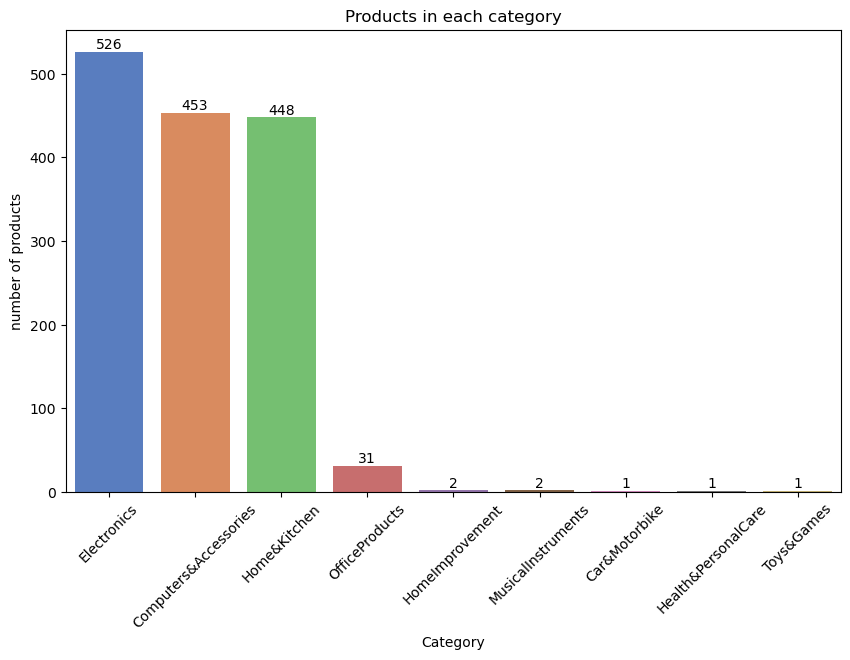

In [45]:
plt.figure(figsize=(10,6))

no_prod=sns.barplot(data=number_of_products,x="Main_category",y="category",palette="muted")

plt.title("Products in each category")
plt.xlabel("Category")
plt.ylabel("number of products")
plt.xticks(rotation=45)

for container in no_prod.containers:
    plt.bar_label(container)
plt.show()


##  Insights
- Electronics has the largest number of listed products.
- Some categories have very few products, indicating a smaller product assortment.
- Amazon appears to focus more heavily on certain product categories.

In [46]:
product_avg_price=data.groupby(by="Main_category",as_index=False)["actual_price"].mean().sort_values(by="actual_price",ascending=False)
product_avg_price

,Main_category,actual_price
2,Electronics,10127.311787
4,Home&Kitchen,4162.073661
0,Car&Motorbike,4000.000000
3,Health&PersonalCare,1900.000000
1,Computers&Accessories,1683.623135
6,MusicalInstruments,1347.000000
5,HomeImprovement,799.000000
7,OfficeProducts,397.193548
8,Toys&Games,150.000000


C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\1566567334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  labels=sns.barplot(data=product_avg_price,x="Main_category",y="actual_price",palette="muted")


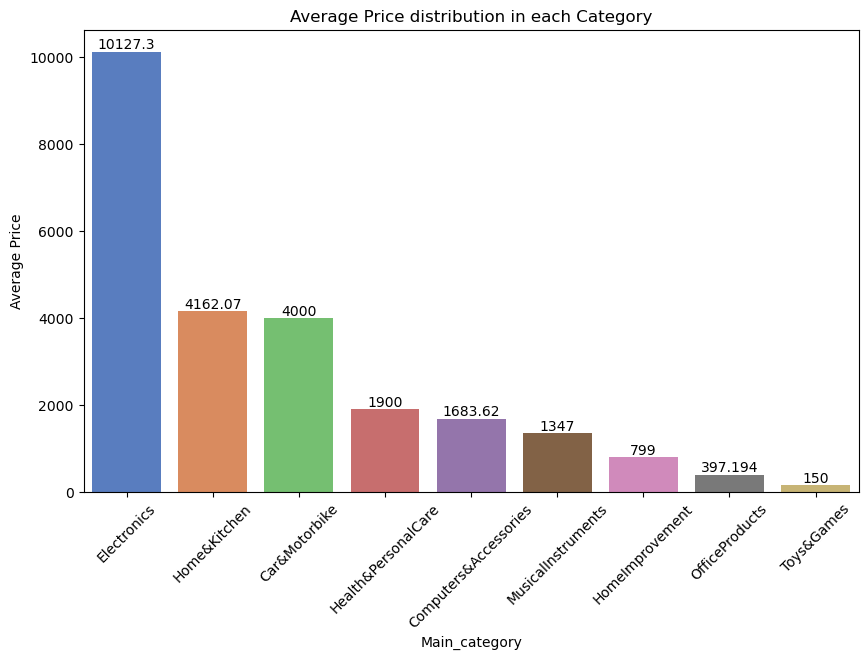

In [47]:
plt.figure(figsize=(10,6))
labels=sns.barplot(data=product_avg_price,x="Main_category",y="actual_price",palette="muted")
plt.title("Average Price distribution in each Category")
plt.xlabel("Main_category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

for container in labels.containers:
    plt.bar_label(container)

plt.show()

## Insights
- Electronics has the highest average selling price.
- Home & Kitchen products are generally more affordable.
- Premium categories tend to have higher listed product prices compared to other categories.

In [48]:
product_avg_rating=data.groupby(by="Main_category",as_index=False)["rating"].mean().sort_values(by="rating",ascending=False)
product_avg_rating

,Main_category,rating
7,OfficeProducts,4.309677
8,Toys&Games,4.300000
5,HomeImprovement,4.250000
1,Computers&Accessories,4.154967
2,Electronics,4.081749
4,Home&Kitchen,4.031696
3,Health&PersonalCare,4.000000
6,MusicalInstruments,3.900000
0,Car&Motorbike,3.800000


C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\63312928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=product_avg_rating,x="Main_category",y="rating",palette="deep")


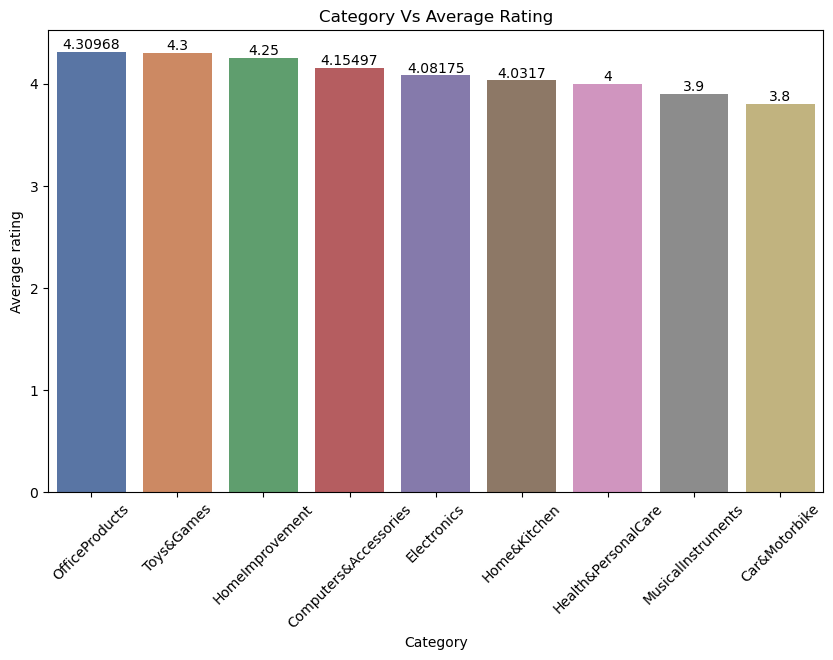

In [49]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=product_avg_rating,x="Main_category",y="rating",palette="deep")
plt.xticks(rotation=45)
plt.title("Category Vs Average Rating")
plt.xlabel("Category")
plt.ylabel("Average rating")

for container in ax.containers:
    plt.bar_label(container)
plt.show()

## Insights
- office Products receive the highest customer ratings.
- Electronics have good ratings but slightly lower than some other categories.
- Categories with lower ratings may need quality improvements.

In [50]:
data["discount_percentage"].describe()

count    1465.000000
mean       47.691468
std        21.635905
min         0.000000
25%        32.000000
50%        50.000000
75%        63.000000
max        94.000000
Name: discount_percentage, dtype: float64

In [51]:
print("Average Discount:", round(data["discount_percentage"].mean(), 2), "%")

Average Discount: 47.69 %


C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\959819686.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


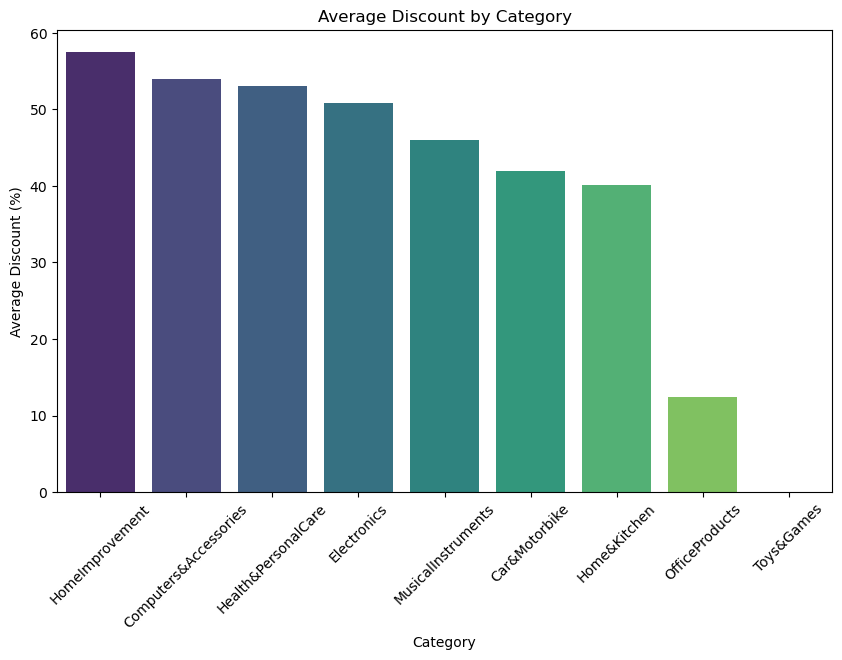

In [53]:
category_discount = (
    data.groupby("Main_category", as_index=False)["discount_percentage"]
        .mean()
        .sort_values(by="discount_percentage", ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_discount,
    x="Main_category",
    y="discount_percentage",
    palette="viridis"
)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45)

plt.show()

## Insights
- Electronics provide the largest average discounts.
- Discount strategies vary significantly by category.

## Univariate Analysis

This section analyzes each variable individually to understand its distribution.

The analysis includes:

- Rating Distribution
- Price Distribution
- Discount Distribution
- Rating Count Distribution

In [54]:
# "Which product categories offer the highest average savings to customers?"
data["Saving"]=data["actual_price"]-data["discounted_price"]

In [56]:
categoryavgsaving=data.groupby(by="Main_category",as_index=False)["Saving"].mean().sort_values(by="Saving",ascending=False)
categoryavgsaving

,Main_category,Saving
2,Electronics,4161.423954
4,Home&Kitchen,1831.458013
0,Car&Motorbike,1661.000000
3,Health&PersonalCare,1001.000000
1,Computers&Accessories,840.972759
6,MusicalInstruments,709.000000
5,HomeImprovement,462.000000
7,OfficeProducts,95.612903
8,Toys&Games,0.000000


C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\1528966742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  amount=sns.barplot(data=categoryavgsaving,x="Main_category",y="Saving",palette="deep")


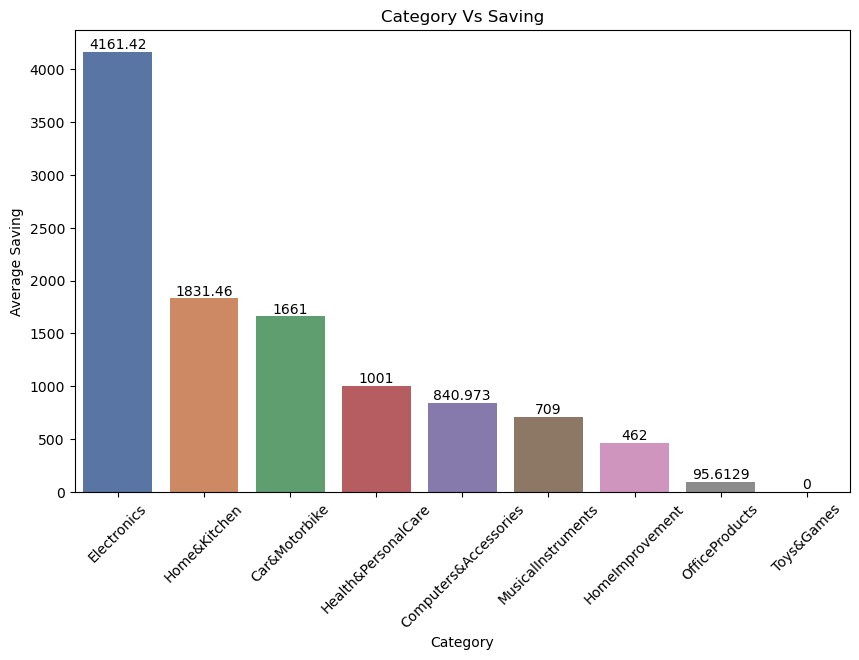

In [57]:
plt.figure(figsize=(10,6))
amount=sns.barplot(data=categoryavgsaving,x="Main_category",y="Saving",palette="deep")
plt.xticks(rotation=45)
plt.title("Category Vs Saving")
plt.xlabel("Category")
plt.ylabel("Average Saving")

for container in amount.containers:
    plt.bar_label(container)
plt.show()

## Analysis
- Categories such as Electronics and Computers & Accessories provide higher average savings than other categories.
- Categories with higher-priced products tend to have larger average savings.
- Customers looking for maximum monetary savings should focus on categories with the highest average discounts in terms of rupee value.

### Rating Distribution

In [58]:
#Most products have ratings above 4
data["rating"].describe()

count    1465.000000
mean        4.093788
std         0.310598
min         0.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

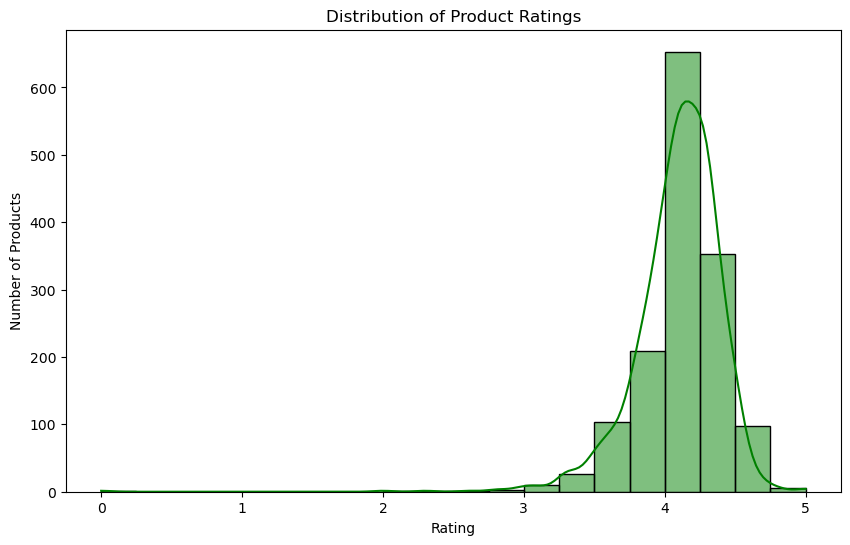

Insights: Most products have rating above 4


In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=data,
    x="rating",
    bins=20,
    kde=True,
    color="green"
)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()
print("Insights: Most products have rating above 4")

## Rating Distribution
Interpretation:
- The average rating is 4.1.
- Most ratings lie between 4.0 and 4.3.
- Very few products have ratings below

In [61]:
## product in each rating
rating_count = data["rating"].value_counts().sort_index()

C:\Users\sweta\AppData\Local\Temp\ipykernel_32056\1135408160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


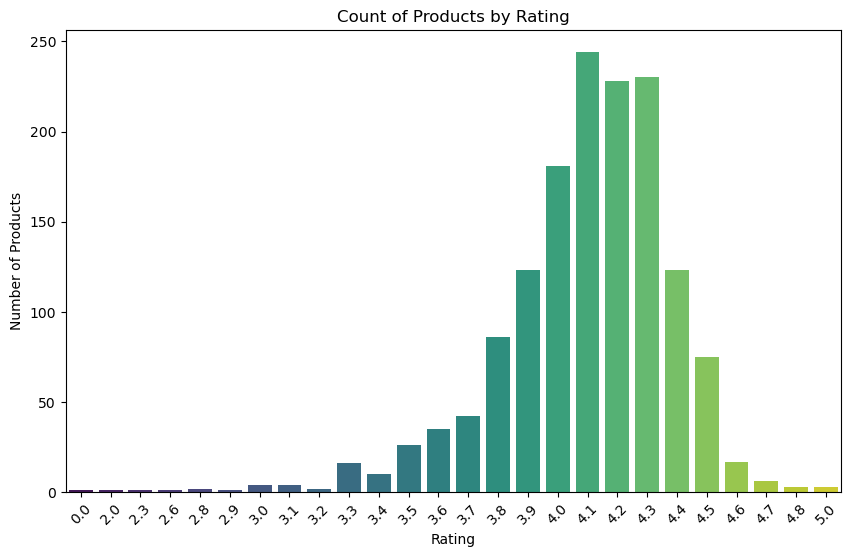

In [62]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x="rating",
    palette="viridis"
)

plt.title("Count of Products by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

In [63]:
# AVerage rating 
print("Average Rating:", round(data["rating"].mean(), 2))

Average Rating: 4.09


In [64]:
# Highly rated Product
high_rating = data[data["rating"] >= 4.5]

print("Products with Rating ≥ 4.5:", len(high_rating))

Products with Rating ≥ 4.5: 104


### Observation

- Most products have ratings between **4.0 and 4.5**.
- The average customer rating is approximately **4.1**, indicating generally positive customer satisfaction.
- Very few products have ratings below **3.5**.
- The distribution is concentrated toward higher ratings, suggesting that most listed products are well received by customers.

## Price Distribution

In [65]:
data["discounted_price"].describe()

count     1465.000000
mean      3125.310874
std       6944.304394
min         39.000000
25%        325.000000
50%        799.000000
75%       1999.000000
max      77990.000000
Name: discounted_price, dtype: float64

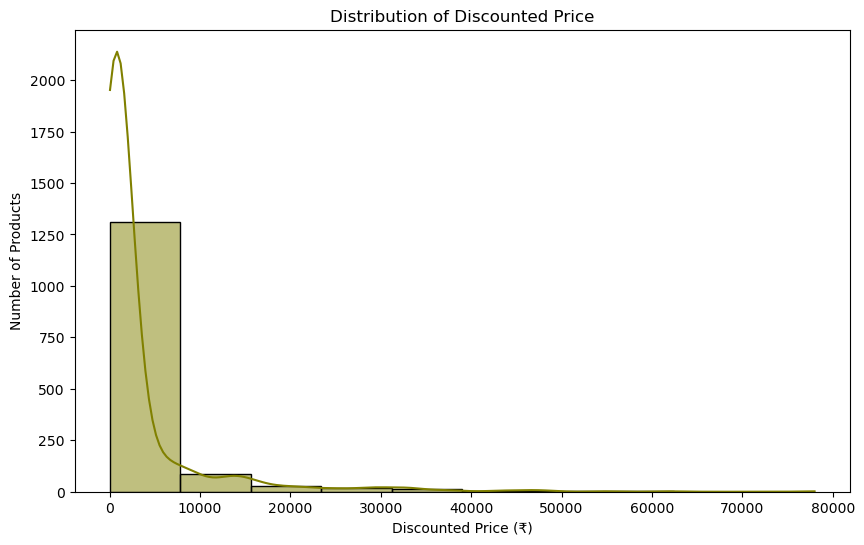

In [66]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=data,
    x="discounted_price",
    bins=10,
    kde=True,
    color="olive"
)

plt.title("Distribution of Discounted Price")
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Number of Products")

plt.show()

In [67]:
print("Average Price:", round(data["discounted_price"].mean(), 2))
print("Median Price:", round(data["discounted_price"].median(), 2))

Average Price: 3125.31
Median Price: 799.0


In [68]:
data.nlargest(10, "discounted_price")[
    ["product_name", "Main_category", "discounted_price"]
]

,product_name,Main_category,discounted_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,Electronics,77990.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,Electronics,61999.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,Electronics,54990.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,Electronics,47990.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,Electronics,47990.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,Electronics,46999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series U...,Electronics,45999.0
533,"OnePlus 10T 5G (Moonstone Black, 8GB RAM, 128G...",Electronics,44999.0
216,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,Electronics,42999.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,Home&Kitchen,42990.0


###  Observation

- Most products are concentrated in the lower price range.
- A few premium products have very high prices, creating a right-skewed distribution.
- The average discounted price is higher than the median, indicating the presence of expensive outliers.
- The majority of Amazon listings are affordable, while only a small number belong to the premium price segment.

## Bivariate Analysis
- Relation between two variables

### Rating Vs Price

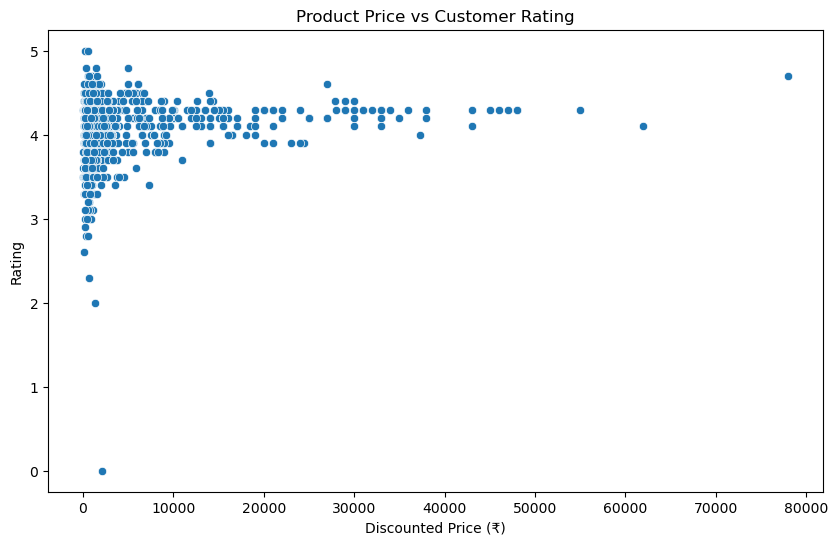

In [70]:
# Do expensive product have higher rating
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="discounted_price",
    y="rating"
)

plt.title("Product Price vs Customer Rating")
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Rating")

plt.show()

### Observation
- The scatter plot shows a weak/no clear relationship between product price and customer rating, suggesting that higher-priced products are not necessarily rated better.

### Discount vs Rating

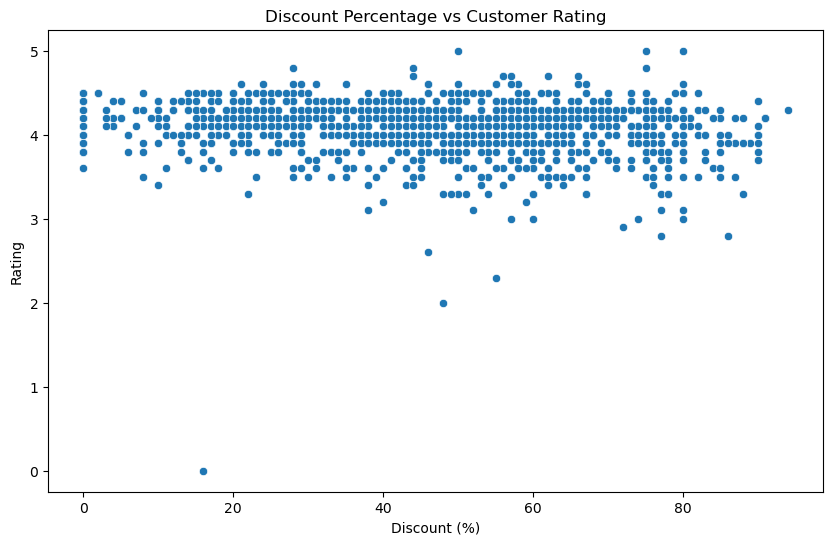

In [71]:
# Do products with higher discounts receive better rating
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="discount_percentage",
    y="rating"
)

plt.title("Discount Percentage vs Customer Rating")
plt.xlabel("Discount (%)")
plt.ylabel("Rating")

plt.show()

### Observation
- Customer ratings remain relatively consistent across different discount levels, indicating that higher discounts do not necessarily correspond to higher customer ratings.

### Price vs Rating Count

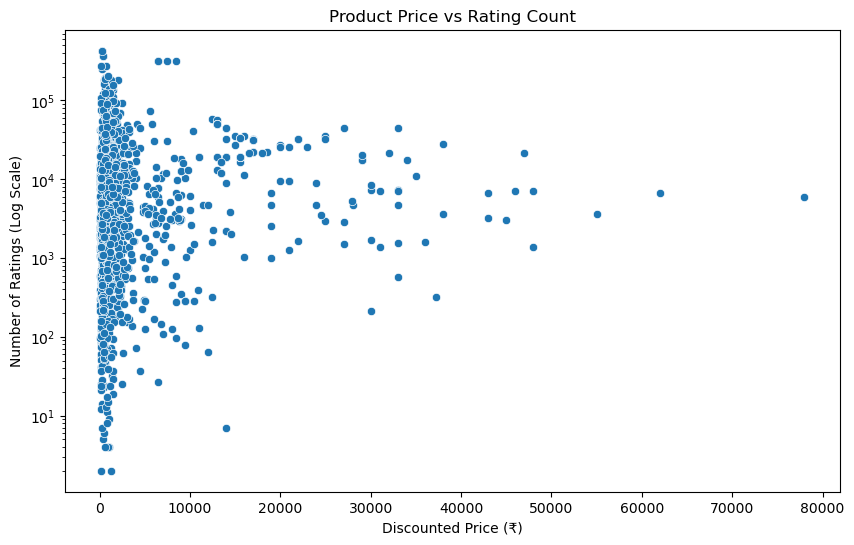

In [74]:
# Do cheaper or expensive products receive more customer engagement?
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="discounted_price",
    y="rating_count"
)

plt.yscale("log")

plt.title("Product Price vs Rating Count")
plt.xlabel("Discounted Price (₹)")
plt.ylabel("Number of Ratings (Log Scale)")

plt.show()

## Correlation Analysis

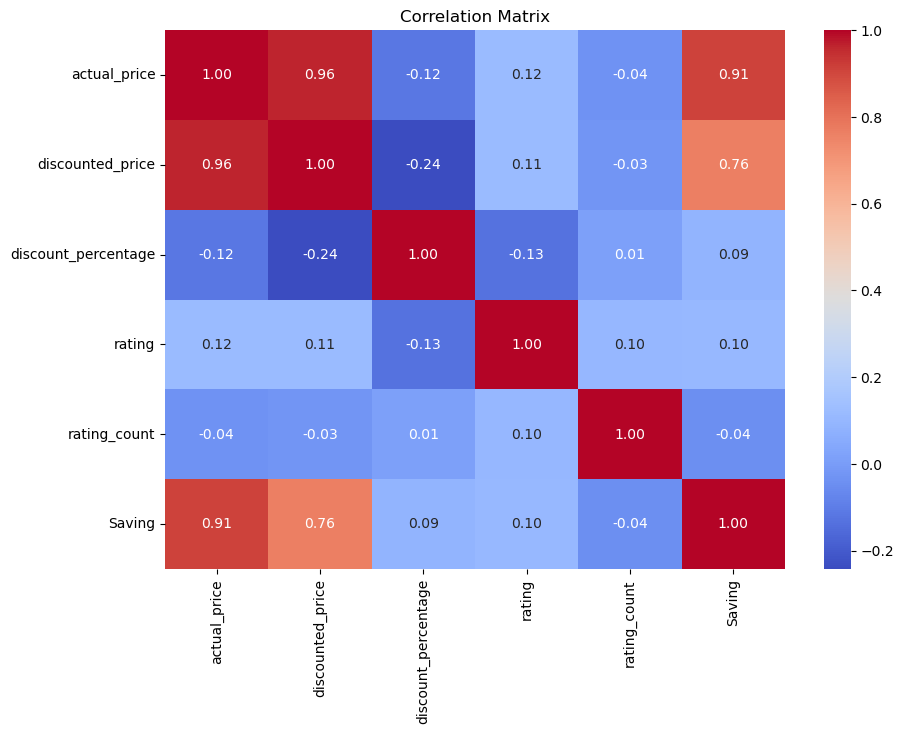

In [78]:
numeric_cols = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count",
    "Saving"
]

correlation = data[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Top 10 Most Reviewed Products

In [79]:
top_reviewed = data.nlargest(10, "rating_count")

top_reviewed[
    ["product_name", "rating", "rating_count", "discounted_price"]
]

,product_name,rating,rating_count,discounted_price
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,219.0
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,309.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,309.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0,219.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,349.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,379.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0,365.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",4.1,313836.0,8499.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",4.1,313836.0,6499.0
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",4.1,313832.0,6499.0


## Top 10 Highest Rated Products

In [80]:
top_rated = data.nlargest(10, "rating")

top_rated[
    ["product_name", "rating", "rating_count"]
]

,product_name,rating,rating_count
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0,NaN
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0,23.0
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803.0
1201,"Oratech Coffee Frother electric, milk frother ...",4.8,28.0
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8,3964.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7,5935.0
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7,7779.0
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7,1729.0
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7,54.0


## Top 10 Highest Discount Products

In [83]:
top_discount = data.nlargest(
    10,
    "discount_percentage"
)[["product_name","discount_percentage","discounted_price"]]

top_discount

,product_name,discount_percentage,discounted_price
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94,294.0
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91,1799.0
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91,1799.0
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91,1799.0
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91,1799.0
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91,1799.0
2,Sounce Fast Phone Charging Cable & Data Sync U...,90,199.0
407,Sounce Spiral Charger Cable Protector Data Cab...,90,99.0
542,Sounce Protective Case Cover Compatible Boat X...,90,199.0
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90,99.0


## Top 10 Products by Savings

In [84]:
top_saving = data.nlargest(
    10,
    "Saving"
)[["product_name","Saving","actual_price","discounted_price"]]

top_saving

,product_name,Saving,actual_price,discounted_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,61910.0,139900.0,77990.0
1182,"Coway Professional Air Purifier for Home, Long...",45500.0,59900.0,14400.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",37009.0,74999.0,37990.0
150,VU 138 cm (55 inches) Premium Series 4K Ultra ...,35010.0,65000.0,29990.0
1354,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,33000.0,75990.0,42990.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,32000.0,79990.0,47990.0
1306,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,32000.0,59900.0,27900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Sma...,30010.0,85000.0,54990.0
108,VU 139 cm (55 inches) The GloLED Series 4K Sma...,27001.0,65000.0,37999.0
323,TCL 108 cm (43 inches) 4K Ultra HD Certified A...,27000.0,51990.0,24990.0


## Business Insights
- 1. Electronics has the largest product assortment in the dataset.

- 2. Most products have ratings above 4, indicating generally positive customer feedback.

- 3. Electronics has the highest average listed price among the major categories.

- 4. Electronics also provides the highest average monetary savings.

- 5. Product price shows a weak relationship with customer rating.

- 6. Higher discounts do not necessarily correspond to higher customer ratings.

- 7. Customer engagement is concentrated among a relatively small number of products.